# Exploration des données acoustiques — `profiles38kHz10t0750m20251006.nc`

Backscatter acoustique (**Sv**, *volume backscattering strength*) issu d'un sondeur de coque à **38 kHz**.

- **541 061 profils** (pings/intervalles) collectés entre **2006 et 2020**
- **75 couches de profondeur** : 10 → 750 m (pas de 10 m)
- **318 fichiers sources** (campagnes navire, BAS / RRS *James Clark Ross*)
- Couverture quasi-globale (Atlantique, Océan Austral)

> ⚠️ À exécuter avec l'environnement conda **`seapopym`** (xarray, netCDF4, pandas, matplotlib installés).

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

PATH = "profiles38kHz10t0750m20251006.nc"
ds = xr.open_dataset(PATH)
ds

<xarray.Dataset> Size: 351MB
Dimensions:     (file_index: 318, time: 541061, range: 75)
Coordinates:
  * file_index  (file_index) int64 3kB 1 2 3 4 5 6 7 ... 313 314 315 316 317 318
  * time        (time) datetime64[ns] 4MB 2008-04-09T10:00:34.000003072 ... 2...
  * range       (range) int64 600B 10 20 30 40 50 60 ... 700 710 720 730 740 750
Data variables:
    file_label  (file_index) <U116 148kB ...
    longitude   (time) float64 4MB ...
    latitude    (time) float64 4MB ...
    file        (time) int64 4MB ...
    interval    (time) float64 4MB ...
    sunangle    (time) float64 4MB ...
    Sv          (range, time) float64 325MB ...
    frequency   |S1 1B ...

## 1. Structure du dataset : dimensions, variables, attributs

In [2]:
print("DIMENSIONS")
for k, v in ds.sizes.items():
    print(f"  {k:12s} = {v}")

print("\nVARIABLES (nom : dims : dtype)")
for name, var in ds.variables.items():
    long = var.attrs.get("long_name", "")
    units = var.attrs.get("units", "")
    u = f" [{units}]" if units else ""
    print(f"  {name:12s} {str(var.dims):28s} {str(var.dtype):10s} {long}{u}")

print("\nATTRIBUTS GLOBAUX")
print("  (aucun)" if not ds.attrs else dict(ds.attrs))

DIMENSIONS
  file_index   = 318
  time         = 541061
  range        = 75

VARIABLES (nom : dims : dtype)
  file_label   ('file_index',)              <U116      File names corresponding to file indexes
  longitude    ('time',)                    float64    Longitude [degrees]
  latitude     ('time',)                    float64    Latitude [degrees]
  file         ('time',)                    int64      File indexes of Sv profiles
  interval     ('time',)                    float64    Horizontal distance interval [m]
  sunangle     ('time',)                    float64    Sun azimuth angle [degrees]
  Sv           ('range', 'time')            float64    Volume backscattering strength [dB re m-1]
  frequency    ()                           |S1        Frequency [kHz]
  file_index   ('file_index',)              int64      File indexes corresponding to file names
  range        ('range',)                   int64      Range [m]
  time         ('time',)                    datetime64[ns] Time

## 2. Coordonnées : profondeur, temps, fréquence, fichiers sources

In [3]:
# Profondeur (range)
rng = ds.range.values
print(f"Profondeur (range) : {rng.min()} → {rng.max()} m, {len(rng)} couches, pas = {np.diff(rng)[0]} m")

# Temps
t = ds.time.values
print(f"\nTemps : {len(t)} pings")
print(f"  début : {pd.Timestamp(t.min())}")
print(f"  fin   : {pd.Timestamp(t.max())}")
print(f"  durée couverte : {(pd.Timestamp(t.max()) - pd.Timestamp(t.min())).days} jours")

# Fréquence (variable scalaire)
print(f"\nFréquence (attr) : {ds.frequency.attrs}  | valeur stockée : {ds.frequency.values}  (=> 38 kHz d'après le nom de fichier)")

# Intervalle horizontal
print(f"\nIntervalle horizontal : {float(ds.interval.min())} → {float(ds.interval.max())} m")

# Fichiers sources
print(f"\nNombre de fichiers sources : {ds.sizes['file_index']}")
print("Exemples de noms de fichiers :")
for lbl in ds.file_label.values[:5]:
    print("  -", lbl)

Profondeur (range) : 10 → 750 m, 75 couches, pas = 10 m

Temps : 541061 pings
  début : 2006-03-10 11:53:46.178560
  fin   : 2020-02-03 01:58:29.307998976
  durée couverte : 5077 jours

Fréquence (attr) : {'units': 'kHz', 'long_name': 'Frequency'}  | valeur stockée : b'3'  (=> 38 kHz d'après le nom de fichier)

Intervalle horizontal : 100.0 → 1852.0 m

Nombre de fichiers sources : 318
Exemples de noms de fichiers :
  - BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AmundsenAndBellingshausenSeas_2008-04-07T11Z_2008-04-10T17Z.nc
  - BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-09-27T16Z_2014-10-01T10Z.nc
  - BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-10-03T14Z_2014-10-17T23Z.nc
  - BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-10-19T17Z_2014-10-24T01Z.nc
  - BAS_SONA_ShipResearch_RRSJamesClarkRoss_M_AtlanticOcean_2014-10-25T18Z_2014-10-26T01Z.nc


## 3. Couverture temporelle

Répartition des pings dans le temps et nombre de pings par fichier source.

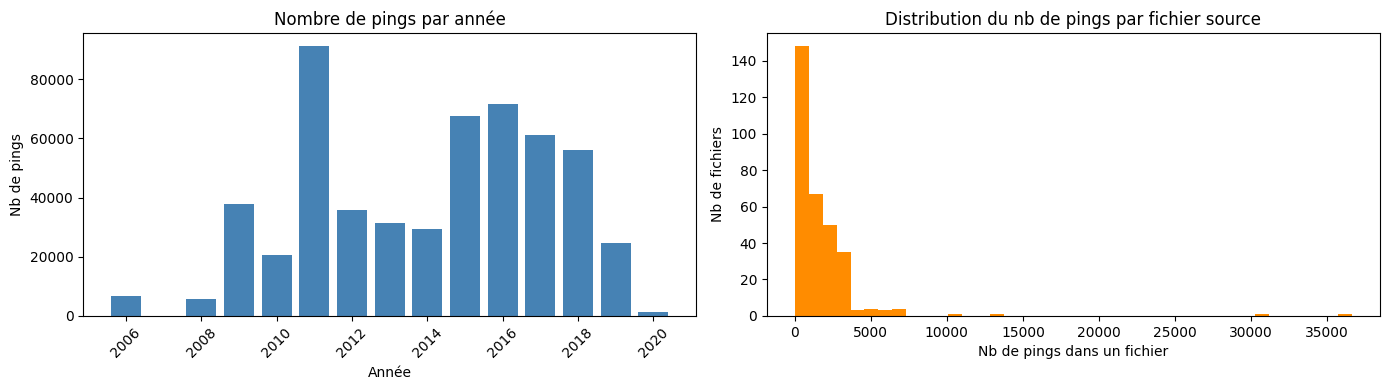

Pings/fichier : min=1, médiane=1091, max=36642


In [4]:
tt = pd.to_datetime(ds.time.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pings par année
per_year = pd.Series(1, index=tt).resample("YE").count()
axes[0].bar(per_year.index.year, per_year.values, color="steelblue")
axes[0].set_title("Nombre de pings par année")
axes[0].set_xlabel("Année"); axes[0].set_ylabel("Nb de pings")
axes[0].tick_params(axis="x", rotation=45)

# Pings par fichier source
counts = pd.Series(ds.file.values).value_counts().sort_index()
axes[1].hist(counts.values, bins=40, color="darkorange")
axes[1].set_title("Distribution du nb de pings par fichier source")
axes[1].set_xlabel("Nb de pings dans un fichier"); axes[1].set_ylabel("Nb de fichiers")

plt.tight_layout(); plt.show()

print(f"Pings/fichier : min={counts.min()}, médiane={int(counts.median())}, max={counts.max()}")

## 4. Couverture géographique

Trajectoires des campagnes (longitude/latitude), colorées par année.

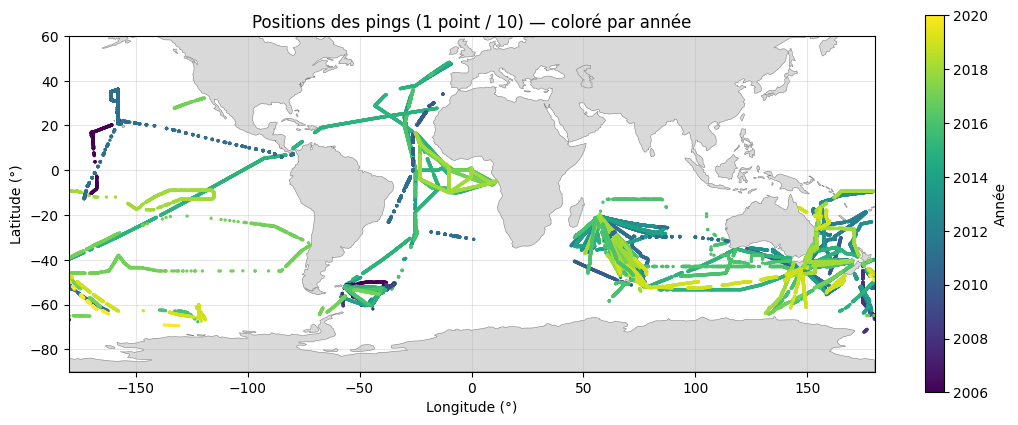

Longitude : -180.00 → 180.00 °
Latitude  : -72.31 → 48.21 °


In [6]:
import json
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

def add_land(ax, path="ne_110m_land.geojson",
             facecolor="0.85", edgecolor="0.5", lw=0.4):
    """Trace les terres (Natural Earth 110m) en fond de carte."""
    gj = json.load(open(path))
    patches = []
    for feat in gj["features"]:
        geom = feat["geometry"]
        polys = geom["coordinates"] if geom["type"] == "Polygon" else \
                [p for mp in geom["coordinates"] for p in mp]
        for ring in polys:
            patches.append(MplPolygon(np.asarray(ring), closed=True))
    ax.add_collection(PatchCollection(patches, facecolor=facecolor,
                                      edgecolor=edgecolor, lw=lw, zorder=0))

lon = ds.longitude.values
lat = ds.latitude.values
year = pd.to_datetime(ds.time.values).year.values

# sous-échantillonnage pour l'affichage
step = max(1, len(lon) // 50000)
fig, ax = plt.subplots(figsize=(13, 7))
add_land(ax)
sc = ax.scatter(lon[::step], lat[::step], c=year[::step], s=2, cmap="viridis", zorder=2)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 60)
ax.set_aspect("equal")
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
ax.set_title(f"Positions des pings (1 point / {step}) — coloré par année")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="Année", shrink=0.7)
plt.show()

print(f"Longitude : {np.nanmin(lon):.2f} → {np.nanmax(lon):.2f} °")
print(f"Latitude  : {np.nanmin(lat):.2f} → {np.nanmax(lat):.2f} °")

## ⚙️ Note méthodologique — dB vs linéaire

Point central en acoustique, qui justifie les conversions `db_to_lin` / `lin_to_db` utilisées dans toute la suite.

### Ce qu'est le Sv en dB

Le Sv (*volume backscattering strength*) est exprimé en **décibels** :

$$S_v\,[\text{dB}] = 10 \cdot \log_{10}(s_v)$$

où $s_v$ est le **coefficient de rétrodiffusion volumique linéaire** (en m⁻¹) : c'est la vraie grandeur physique, proportionnelle à la quantité de diffuseurs (organismes) dans le volume d'eau insonifié. C'est elle qui est **additive** et qui a un sens physique direct.

Le dB n'est qu'une **échelle logarithmique** de cette grandeur. On l'utilise parce que :
- les valeurs physiques couvrent plusieurs ordres de grandeur (un banc dense rétrodiffuse des milliards de fois plus que de l'eau claire) → le log compresse tout dans une plage lisible (~ −120 à −30 dB ici) ;
- c'est la convention historique du sonar.

### Pourquoi convertir avant de moyenner

**On ne peut pas faire de moyenne arithmétique sur des dB.** Le logarithme n'est pas linéaire, donc la moyenne des dB ≠ le dB de la moyenne :

$$\overline{S_v} \neq 10\log_{10}\big(\overline{s_v}\big)$$

Ce qui a un sens physique c'est la **quantité moyenne de diffuseurs**, donc on moyenne dans le domaine **linéaire** puis on reconvertit :

1. `sv_lin = 10**(Sv/10)` → retour à la grandeur physique
2. `mean = np.nanmean(sv_lin)` → moyenne physiquement correcte (additive)
3. `lin_to_db(mean) = 10*log10(mean)` → réaffichage en dB

### L'écart est-il significatif ?

Oui, et les données le montrent (cf. cellule de stats ci-dessous) :

```
moyenne (dB direct) = -75.88 dB
moyenne (linéaire)  = -70.58 dB
```

**≈ 5,3 dB d'écart**, soit un facteur ~3,4 en linéaire ($10^{5.3/10} \approx 3.4$). La moyenne en dB *sous-estime* fortement : la moyenne linéaire est dominée par les valeurs fortes (agrégations denses, rares mais intenses) qui portent l'essentiel de la biomasse, alors que le log écrase ces pics. C'est pourquoi en bio-acoustique on intègre toujours en linéaire (principe du **NASC**, proxy de biomasse).

### Règle pratique

| Opération | Domaine |
|---|---|
| Moyenner, sommer, intégrer (NASC), agréger | **linéaire**, puis reconvertir |
| Afficher, comparer visuellement, colorbar, seuils | **dB** |
| Soustraire deux Sv (ex. ΔSv jour − nuit) | **dB** — une différence de dB = un *ratio* linéaire, ce qu'on veut |

> Dernière ligne : c'est pourquoi la cellule jour/nuit calcule `prof_day − prof_night` directement en dB. La différence de deux log est le log d'un rapport, donc **ΔSv = +3 dB ⟺ 2× plus de diffuseurs** — interprétation directe et légitime.

## 5. Chargement du Sv et statistiques globales

`Sv` a la forme `(range=75, time=541061)` soit ~324 Mo. On le charge une fois en mémoire et on le réutilise dans les cellules suivantes.

Le Sv est en **dB** : pour moyenner correctement on repasse en domaine **linéaire** (`sv_lin = 10**(Sv/10)`) avant de remoyenner et reconvertir.

In [7]:
sv = ds.Sv.values  # (range, time) en dB
print("Forme Sv :", sv.shape, "| dtype :", sv.dtype, "| taille :", sv.nbytes / 1e6, "Mo")

def db_to_lin(x):
    return 10.0 ** (x / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(x)

print("\nStatistiques Sv (dB) :")
print(f"  min    = {np.nanmin(sv):.2f}")
print(f"  max    = {np.nanmax(sv):.2f}")
print(f"  moyenne (dB direct) = {np.nanmean(sv):.2f}")
print(f"  moyenne (linéaire)  = {lin_to_db(np.nanmean(db_to_lin(sv))):.2f}")
print(f"  fraction de NaN     = {np.isnan(sv).mean():.4f}")

Forme Sv : (75, 541061) | dtype : float64 | taille : 324.6366 Mo

Statistiques Sv (dB) :
  min    = -129.00
  max    = -30.85
  moyenne (dB direct) = -75.88
  moyenne (linéaire)  = -70.58
  fraction de NaN     = 0.0401


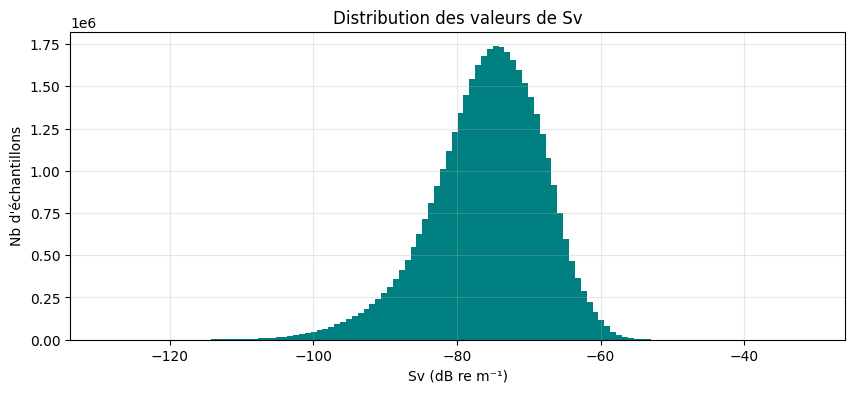

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sv[np.isfinite(sv)].ravel(), bins=120, color="teal")
ax.set_xlabel("Sv (dB re m⁻¹)"); ax.set_ylabel("Nb d'échantillons")
ax.set_title("Distribution des valeurs de Sv")
ax.grid(alpha=0.3)
plt.show()

## 6. Profil vertical moyen de Sv

Sv moyen (moyenne linéaire) en fonction de la profondeur.

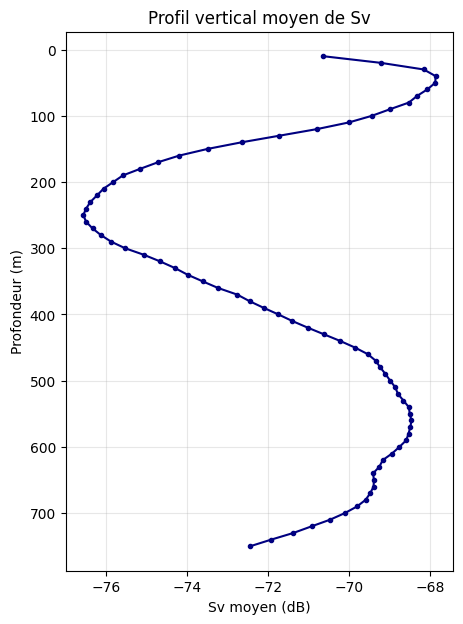

In [9]:
mean_profile = lin_to_db(np.nanmean(db_to_lin(sv), axis=1))  # moyenne sur le temps

fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(mean_profile, rng, "-o", ms=3, color="navy")
ax.invert_yaxis()
ax.set_xlabel("Sv moyen (dB)"); ax.set_ylabel("Profondeur (m)")
ax.set_title("Profil vertical moyen de Sv")
ax.grid(alpha=0.3)
plt.show()

## 7. Échogramme global (vue d'ensemble)

Sv en fonction de la profondeur et de l'indice de ping. 541 061 colonnes étant trop pour l'écran, on agrège par blocs (moyenne linéaire) pour obtenir ~2000 colonnes.

/tmp/ipykernel_2277725/3711101388.py:9: RuntimeWarning: Mean of empty slice
  echo = lin_to_db(np.nanmean(sv_lin, axis=2))  # (range, ncols)


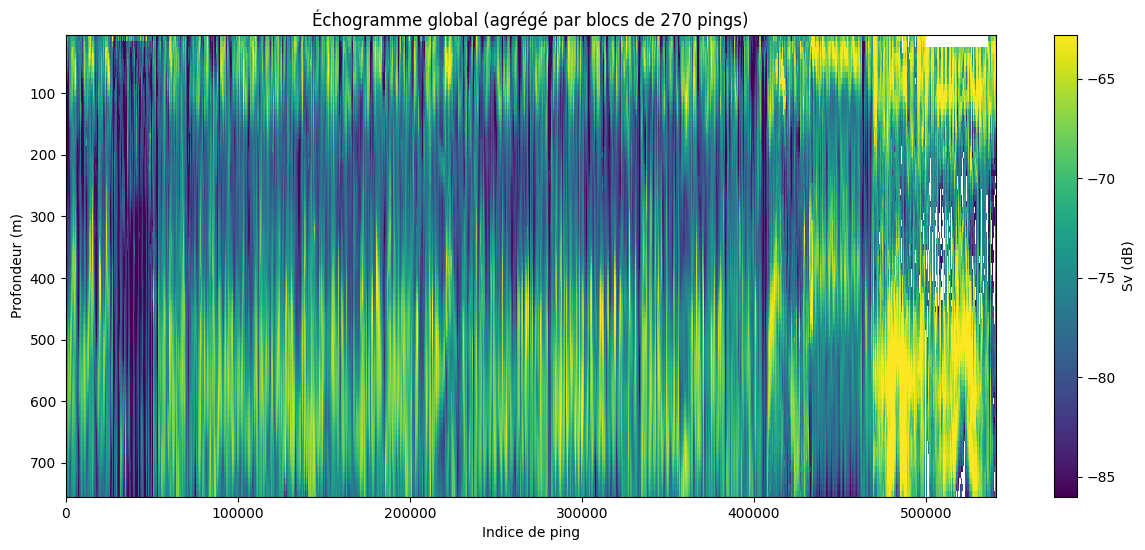

In [10]:
ntime = sv.shape[1]
target_cols = 2000
block = max(1, ntime // target_cols)
ncols = ntime // block

# agrégation par blocs en domaine linéaire
sv_lin = db_to_lin(sv[:, : ncols * block])
sv_lin = sv_lin.reshape(sv.shape[0], ncols, block)
echo = lin_to_db(np.nanmean(sv_lin, axis=2))  # (range, ncols)
del sv_lin

fig, ax = plt.subplots(figsize=(15, 6))
pcm = ax.pcolormesh(np.arange(ncols) * block, rng, echo, cmap="viridis",
                    vmin=np.nanpercentile(echo, 2), vmax=np.nanpercentile(echo, 98))
ax.invert_yaxis()
ax.set_xlabel("Indice de ping"); ax.set_ylabel("Profondeur (m)")
ax.set_title(f"Échogramme global (agrégé par blocs de {block} pings)")
plt.colorbar(pcm, ax=ax, label="Sv (dB)")
plt.show()

## 8. Échogramme détaillé sur un segment continu

Zoom pleine résolution sur un segment de pings appartenant à un seul fichier source (trajectoire continue).

Fichier 317 : 36642 pings
  domokos_20110311_20110326.nc


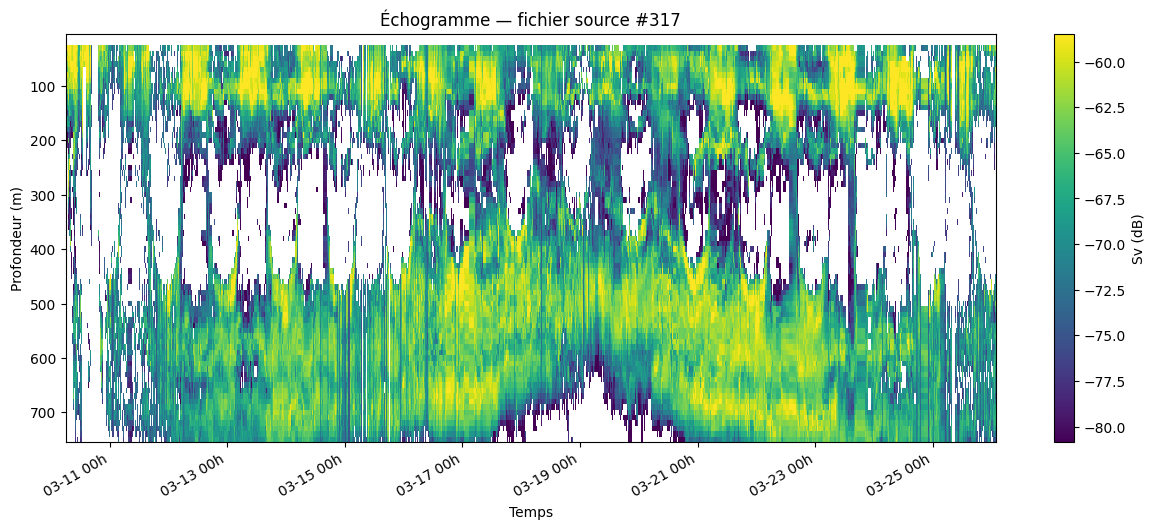

In [11]:
# on choisit le fichier source contenant le plus de pings
file_ids, file_counts = np.unique(ds.file.values, return_counts=True)
best_file = file_ids[file_counts.argmax()]
sel = np.where(ds.file.values == best_file)[0]
i0, i1 = sel.min(), sel.max() + 1
label = ds.file_label.sel(file_index=best_file).item()
print(f"Fichier {best_file} : {i1 - i0} pings\n  {label}")

seg = sv[:, i0:i1]
seg_t = pd.to_datetime(ds.time.values[i0:i1])

fig, ax = plt.subplots(figsize=(15, 6))
pcm = ax.pcolormesh(seg_t, rng, seg, cmap="viridis",
                    vmin=np.nanpercentile(seg, 2), vmax=np.nanpercentile(seg, 98))
ax.invert_yaxis()
ax.set_xlabel("Temps"); ax.set_ylabel("Profondeur (m)")
ax.set_title(f"Échogramme — fichier source #{best_file}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
fig.autofmt_xdate()
plt.colorbar(pcm, ax=ax, label="Sv (dB)")
plt.show()

## 9. Effet jour / nuit (migration verticale)

La variable `sunangle` (valeurs ~ -90 → +90°) se comporte comme une **élévation solaire** : > 0° = jour, < 0° = nuit. On compare les profils verticaux moyens jour vs nuit — la migration verticale nycthémérale du zooplancton/micronecton doit apparaître.

Pings jour  :   276534
Pings nuit  :   264527


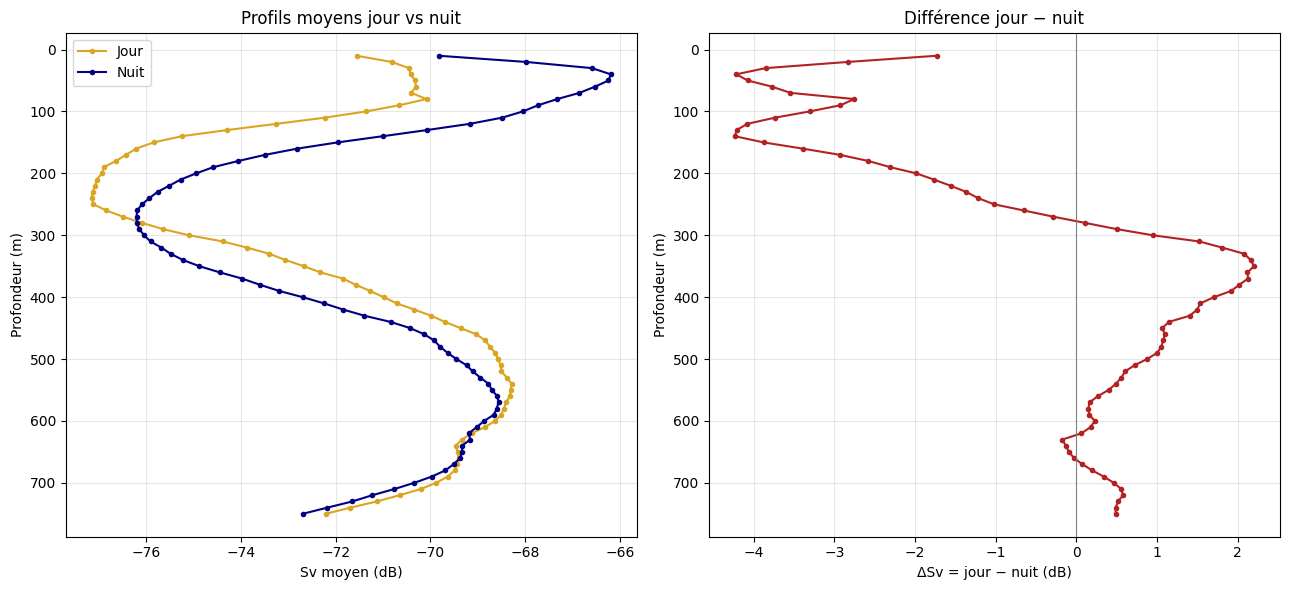

In [12]:
sun = ds.sunangle.values
is_day = sun > 0
is_night = sun < 0
print(f"Pings jour  : {is_day.sum():>8d}")
print(f"Pings nuit  : {is_night.sum():>8d}")

prof_day = lin_to_db(np.nanmean(db_to_lin(sv[:, is_day]), axis=1))
prof_night = lin_to_db(np.nanmean(db_to_lin(sv[:, is_night]), axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].plot(prof_day, rng, "-o", ms=3, label="Jour", color="goldenrod")
axes[0].plot(prof_night, rng, "-o", ms=3, label="Nuit", color="navy")
axes[0].invert_yaxis(); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Sv moyen (dB)"); axes[0].set_ylabel("Profondeur (m)")
axes[0].set_title("Profils moyens jour vs nuit")

axes[1].plot(prof_day - prof_night, rng, "-o", ms=3, color="firebrick")
axes[1].axvline(0, color="grey", lw=0.8)
axes[1].invert_yaxis(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("ΔSv = jour − nuit (dB)"); axes[1].set_ylabel("Profondeur (m)")
axes[1].set_title("Différence jour − nuit")
plt.tight_layout(); plt.show()

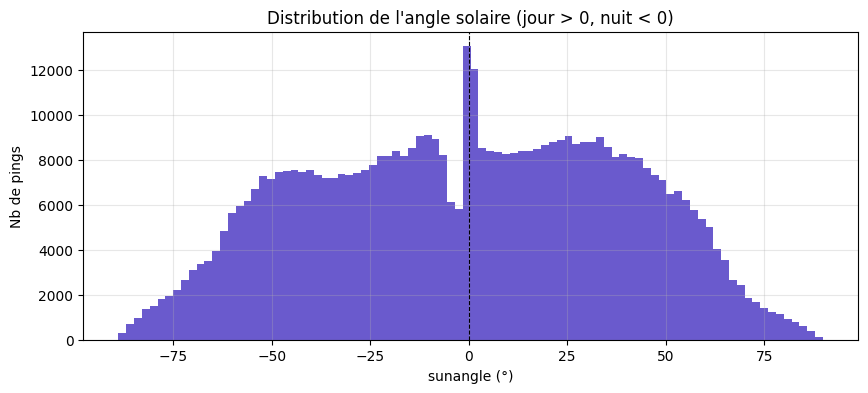

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sun[np.isfinite(sun)], bins=90, color="slateblue")
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("sunangle (°)"); ax.set_ylabel("Nb de pings")
ax.set_title("Distribution de l'angle solaire (jour > 0, nuit < 0)")
ax.grid(alpha=0.3)
plt.show()

## Résumé

- Dataset = **échogramme 38 kHz** : Sv(profondeur, temps) sur 75 couches × 541 061 pings, 2006–2020.
- Couverture géographique large (Atlantique + Océan Austral), 318 campagnes navire.
- Valeurs Sv typiques entre ~−120 et ~−50 dB.
- Le profil vertical moyen et le contraste **jour/nuit** révèlent la structure biologique (couches diffusantes, migration verticale).

Pistes : filtrer par région (lon/lat) ou par saison, calculer le NASC intégré, ou comparer plusieurs campagnes.